# Problem Set 1

This notebook:
1) loads labels + features
2) builds train/val/test split
3) trains: Linear Regression, KNN, MLP
4) tunes hyperparameters + tests seed sensitivity
5) reports test RMSE + plots (parity plots)

(This notebook contains codes from get_data.ipynb and help from ChatGPT)

In [19]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.neighbors import KNeighborsRegressor  

### 1) Load labels and make the RGB subset
Followed the provided get_data logic: select stars with TEFF/LOGG/H cuts, then make train/val/test.

In [20]:

path_labels = "./labels.fits"


allstar = fits.open(path_labels)
labels = allstar[1].data


RGB = True
RGB = np.logical_and(RGB, labels["TEFF"] > 3500.)
RGB = np.logical_and(RGB, labels["TEFF"] < 5400.)
RGB = np.logical_and(RGB, labels["LOGG"] < 3.0)
RGB = np.logical_and(RGB, labels["LOGG"] > 0.0)
RGB = np.logical_and(RGB, labels["H"] < 10.5)

RGB_labels = labels[RGB]


rng = np.random.default_rng(17)
N_RGB = len(RGB_labels)
N_train, N_valid, N_test = 1024, 256, 512

I = rng.permutation(N_RGB)
I_train = I[:N_train]
I_valid = I[N_train:N_train+N_valid]
I_test  = I[N_train+N_valid:N_train+N_valid+N_test]

train_labels = RGB_labels[I_train]
valid_labels = RGB_labels[I_valid]
test_labels  = RGB_labels[I_test]

print("Split sizes:", len(train_labels), len(valid_labels), len(test_labels))

Split sizes: 1024 256 512


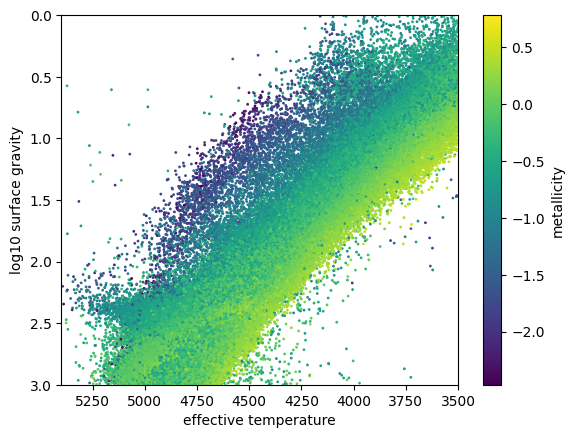

In [21]:
RGB_labels = labels[RGB]
plt.scatter(RGB_labels['TEFF'], RGB_labels['LOGG'], c=RGB_labels['FE_H'], s=1)
plt.xlim(5400, 3500)
plt.xlabel("effective temperature")
plt.ylim(3., 0.)
plt.ylabel("log10 surface gravity")
plt.colorbar(label="metallicity")

### 2) Load features and standardize
normalize using training mean/std, then apply same transform to val/test.

In [22]:
train_features = np.load("./train_features.npy")
valid_features = np.load("./valid_features.npy")
test_features  = np.load("./test_features.npy")

mu = train_features.mean(axis=0, keepdims=True)
sig = train_features.std(axis=0, keepdims=True) + 1e-8

train_features = (train_features - mu) / sig
valid_features = (valid_features - mu) / sig
test_features  = (test_features  - mu) / sig

print("train_features shape:", train_features.shape)
print("valid_features shape:", valid_features.shape)
print("test_features shape :", test_features.shape)

train_features shape: (1024, 8575)
valid_features shape: (256, 8575)
test_features shape : (512, 8575)


### 3) Extract target y = LOGG and make helper metric (RMSE) + parity plot

In [23]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def parity_plot(y_true, y_pred, title="Parity plot"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure()
    plt.scatter(y_true, y_pred, s=8)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("True LOGG")
    plt.ylabel("Predicted LOGG")
    plt.title(title)
    plt.show()

y_train = np.array(train_labels["LOGG"], dtype=np.float32)
y_valid = np.array(valid_labels["LOGG"], dtype=np.float32)
y_test  = np.array(test_labels["LOGG"], dtype=np.float32)

print("LOGG ranges:", y_train.min(), y_train.max())

LOGG ranges: 0.10792018 2.9974935


### 4) Linear Regression
A single linear layer: y_hat = Wx + b.
Train on train set, pick hyperparameters using validation RMSE.

In [24]:
def make_loaders(batch_size=32):
    Xtr = torch.tensor(train_features, dtype=torch.float32)
    Xva = torch.tensor(valid_features, dtype=torch.float32)
    Xte = torch.tensor(test_features,  dtype=torch.float32)

    ytr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    yva = torch.tensor(y_valid, dtype=torch.float32).view(-1, 1)
    yte = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(TensorDataset(Xva, yva), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(Xte, yte), batch_size=batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

def train_torch_model(model, train_loader, valid_loader, *,
                      epochs=50, lr=1e-3, seed=0):
    torch.manual_seed(seed)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses, valid_losses = [], []

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        total = 0.0
        n = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        train_mse = total / n

        # ---- valid ----
        model.eval()
        total = 0.0
        n = 0
        with torch.no_grad():
            for xb, yb in valid_loader:
                pred = model(xb)
                loss = loss_fn(pred, yb)
                total += loss.item() * xb.size(0)
                n += xb.size(0)
        valid_mse = total / n

        train_losses.append(train_mse)
        valid_losses.append(valid_mse)

    return np.array(train_losses), np.array(valid_losses)

def predict_numpy(model, X_np):
    model.eval()
    with torch.no_grad():
        X = torch.tensor(X_np, dtype=torch.float32)
        yhat = model(X).cpu().numpy().reshape(-1)
    return yhat

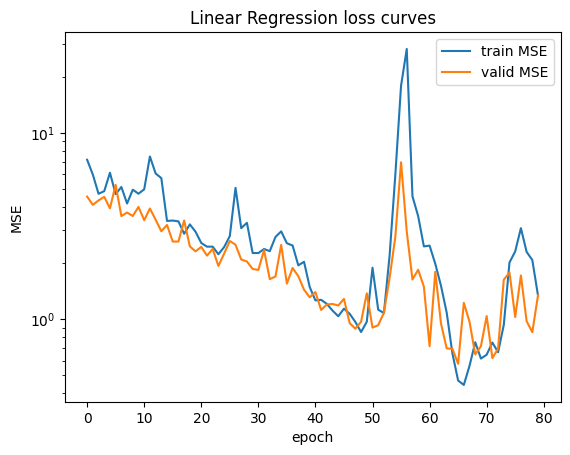

Linear valid RMSE: 1.160296


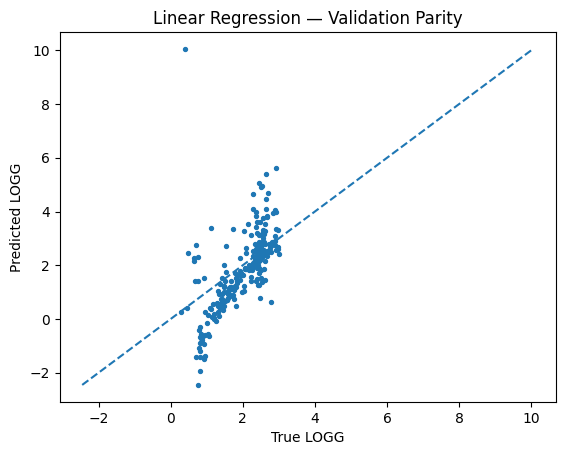

In [25]:
train_loader, valid_loader, test_loader = make_loaders(batch_size=32)

d = train_features.shape[1]
lin = nn.Linear(d, 1)

train_losses, valid_losses = train_torch_model(lin, train_loader, valid_loader,
                                               epochs=80, lr=1e-3, seed=0)

plt.figure()
plt.plot(train_losses, label="train MSE")
plt.plot(valid_losses, label="valid MSE")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Linear Regression loss curves")
plt.legend()
plt.show()

yhat_valid = predict_numpy(lin, valid_features)
print("Linear valid RMSE:", rmse(y_valid, yhat_valid))
parity_plot(y_valid, yhat_valid, "Linear Regression — Validation Parity")

### 5) KNN Regression 
Tune k using validation RMSE.

k= 1  valid RMSE=0.2595
k= 3  valid RMSE=0.2420
k= 5  valid RMSE=0.2281
k=10  valid RMSE=0.2346
k=20  valid RMSE=0.2538
k=30  valid RMSE=0.2690

Best k: 5 valid RMSE: 0.22814932


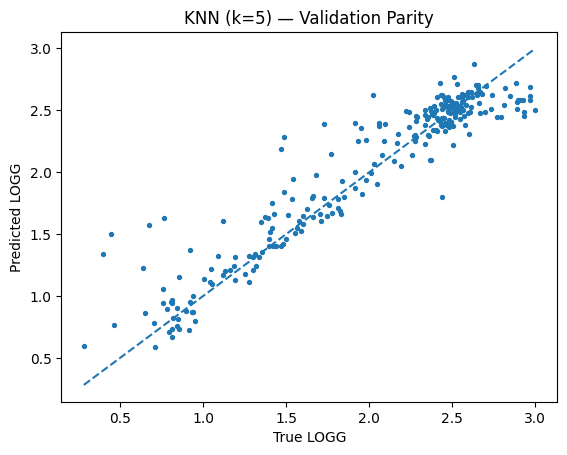

In [26]:
k_list = [1, 3, 5, 10, 20, 30]
best = None

for k in k_list:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(train_features, y_train)
    pred_val = knn.predict(valid_features)
    val_rmse = rmse(y_valid, pred_val)
    print(f"k={k:>2}  valid RMSE={val_rmse:.4f}")
    if (best is None) or (val_rmse < best["rmse"]):
        best = {"k": k, "rmse": val_rmse, "model": knn}

print("\nBest k:", best["k"], "valid RMSE:", best["rmse"])
parity_plot(y_valid, best["model"].predict(valid_features), f"KNN (k={best['k']}) — Validation Parity")

### 6) MLP 
We tune: hidden sizes, learning rate, epochs, activation, and random seed.

In [27]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, activation=nn.ReLU()):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(d, h))
            layers.append(activation)
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

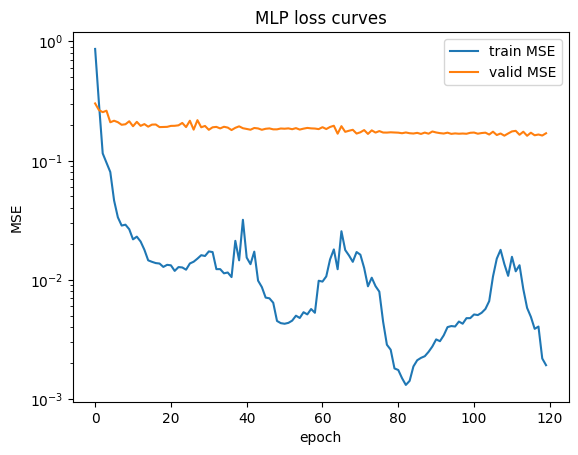

MLP valid RMSE: 0.41129762


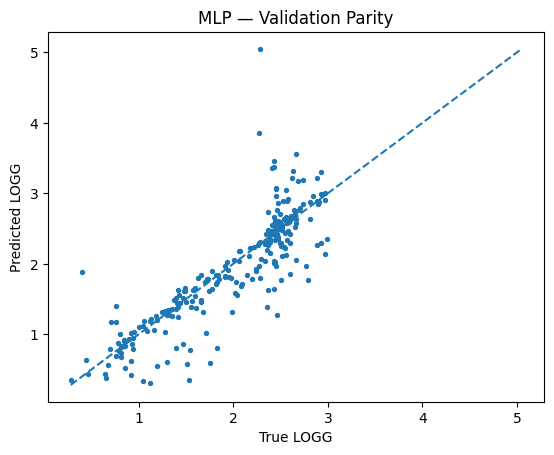

In [28]:
train_loader, valid_loader, test_loader = make_loaders(batch_size=32)

mlp = MLP(input_dim=train_features.shape[1], hidden_dims=[64, 32], activation=nn.LeakyReLU())

train_losses, valid_losses = train_torch_model(mlp, train_loader, valid_loader,
                                               epochs=120, lr=1e-3, seed=0)

plt.figure()
plt.plot(train_losses, label="train MSE")
plt.plot(valid_losses, label="valid MSE")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("MLP loss curves")
plt.legend()
plt.show()

yhat_valid = predict_numpy(mlp, valid_features)
print("MLP valid RMSE:", rmse(y_valid, yhat_valid))
parity_plot(y_valid, yhat_valid, "MLP — Validation Parity")

### 7) Hyperparameter tuning + seed sensitivity
For KNN & MLP we also vary RNG seeds and see if results are stable.

In [ ]:
results = []


for lr in [1e-3, 3e-4]:
    for seed in [0, 1, 2]:
        lin = nn.Linear(train_features.shape[1], 1)
        train_loader, valid_loader, _ = make_loaders(batch_size=32)
        train_torch_model(lin, train_loader, valid_loader, epochs=80, lr=lr, seed=seed)
        pred_val = predict_numpy(lin, valid_features)
        results.append(("Linear", {"lr": lr, "seed": seed}, rmse(y_valid, pred_val)))

for k in [3, 5, 10, 20]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(train_features, y_train)
    pred_val = knn.predict(valid_features)
    results.append(("KNN", {"k": k}, rmse(y_valid, pred_val)))


for hidden in [[64, 32], [128, 64]]:
    for seed in [0, 1, 2]:
        mlp = MLP(train_features.shape[1], hidden, activation=nn.LeakyReLU())
        train_loader, valid_loader, _ = make_loaders(batch_size=32)
        train_torch_model(mlp, train_loader, valid_loader, epochs=120, lr=1e-3, seed=seed)
        pred_val = predict_numpy(mlp, valid_features)
        results.append(("MLP", {"hidden": hidden, "seed": seed}, rmse(y_valid, pred_val)))


results_sorted = sorted(results, key=lambda x: x[2])
for model_name, cfg, score in results_sorted[:10]:
    print(model_name, cfg, "valid RMSE =", round(score, 4))

### 8) Final model selection and test evaluation

Best validation configs:
Linear: {'lr': 0.001, 'seed': 1} val RMSE = 0.8029
KNN   : {'k': 5} val RMSE = 0.2281
MLP   : {'hidden': [128, 64], 'seed': 2} val RMSE = 0.3702

TEST RMSE:
Linear: 0.7018
KNN   : 0.2221
MLP   : 0.2728

Best on TEST: KNN RMSE = 0.2221


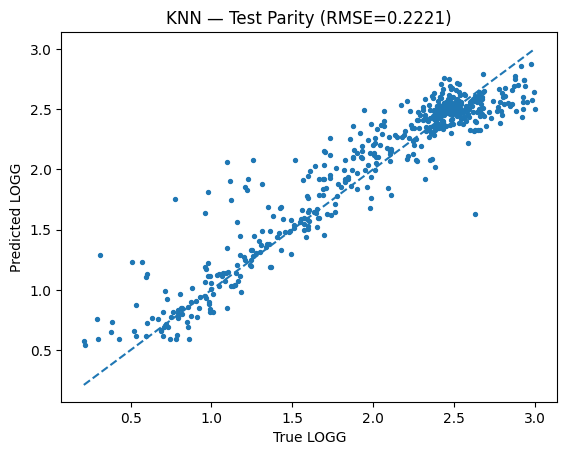

In [ ]:

X_trainval = np.vstack([train_features, valid_features])
y_trainval = np.concatenate([y_train, y_valid])

def make_loaders_from_arrays(Xtr, ytr, Xte, yte, batch_size=32):
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32).view(-1, 1)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)
    yte_t = torch.tensor(yte, dtype=torch.float32).view(-1, 1)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def eval_torch_rmse(model, X_np, y_np):
    pred = predict_numpy(model, X_np)
    return rmse(y_np, pred), pred


best_linear = next(r for r in results_sorted if r[0] == "Linear")
best_knn    = next(r for r in results_sorted if r[0] == "KNN")
best_mlp    = next(r for r in results_sorted if r[0] == "MLP")

print("Best validation configs:")
print("Linear:", best_linear[1], "val RMSE =", round(best_linear[2], 4))
print("KNN   :", best_knn[1],    "val RMSE =", round(best_knn[2], 4))
print("MLP   :", best_mlp[1],    "val RMSE =", round(best_mlp[2], 4))



# Linear
torch.manual_seed(best_linear[1]["seed"])
lin_final = nn.Linear(train_features.shape[1], 1)
train_loader, _ = make_loaders_from_arrays(X_trainval, y_trainval, test_features, y_test, batch_size=32)
train_torch_model(lin_final, train_loader, train_loader, epochs=80, lr=best_linear[1]["lr"], seed=best_linear[1]["seed"])
lin_test_rmse, lin_pred_test = eval_torch_rmse(lin_final, test_features, y_test)

# KNN
knn_final = KNeighborsRegressor(n_neighbors=best_knn[1]["k"])
knn_final.fit(X_trainval, y_trainval)
knn_pred_test = knn_final.predict(test_features)
knn_test_rmse = rmse(y_test, knn_pred_test)

# MLP
torch.manual_seed(best_mlp[1]["seed"])
mlp_final = MLP(train_features.shape[1], best_mlp[1]["hidden"], activation=nn.LeakyReLU())
train_loader, _ = make_loaders_from_arrays(X_trainval, y_trainval, test_features, y_test, batch_size=32)
train_torch_model(mlp_final, train_loader, train_loader, epochs=120, lr=1e-3, seed=best_mlp[1]["seed"])
mlp_test_rmse, mlp_pred_test = eval_torch_rmse(mlp_final, test_features, y_test)

print("\nTEST RMSE:")
print("Linear:", round(lin_test_rmse, 4))
print("KNN   :", round(knn_test_rmse, 4))
print("MLP   :", round(mlp_test_rmse, 4))

rmses = {
    "Linear": (lin_test_rmse, lin_pred_test),
    "KNN":    (knn_test_rmse, knn_pred_test),
    "MLP":    (mlp_test_rmse, mlp_pred_test),
}
best_name = min(rmses, key=lambda k: rmses[k][0])
best_rmse, best_pred = rmses[best_name]
print("\nBest on TEST:", best_name, "RMSE =", round(best_rmse, 4))

parity_plot(y_test, best_pred, f"{best_name} — Test Parity (RMSE={best_rmse:.4f})")

 ### Final Project: First Step

 For my final project, if plausible, I plan to build a machine learning model to predict a signal that indicates whether buying a particular stock will be helpful or not . There are plenty of data accessible from online.